In [1]:
import torch
import pandas as pd
import numpy as np
import os,re,collections
f_c= set(["at", "in", "is", "there", "on", "to", "are", "for", "has", "not", "their" ,"is", "while", "and", "by", "with", "from", "are", "one", "no", "another", "this", "these", "that", "those", "my", "our", "your", "his", "her", "its", "their", "some", "any", "every", "other", "many", "more", "most", "enough", "few", "less", "much", "either", "neither", "several", "all", "both", "each", "one", "two", "three", "four", "first", "second", "third" ,"last", "can", "have", "be", "do", "could", "has", "am", "does", "will", "had", "is", "did", "would", "having", "are", "done", "shall", "was", "doing", "should", "were", "may", "been", "might", "being", "must", "but", "or", "yet", "nor", "for", "so", "before", "once", "since", "until", "when", "while", "as", "like",  "although", "though", "whereas", "while", "except", "because", "since", "if", "where", "when", "why", "whom", "whose", "which", "what", "how"])

def get_indiv_concepts(expls) -> set:
    concepts = set()
    concps = re.findall(r'\b(?:NOT )?(?:pre:tok:|pre:tag:|hyp:tag:|hyp:tok:|oth:)\S*', expls)
    for i,_ in enumerate(concps):
        while concps[i][-1] == ')':
            concps[i] = concps[i][:-1]
        concepts.add(concps[i])
    return concepts
                

def nonconvg(base, clus):
    inexplainable = collections.defaultdict(list)
    num_neurons = collections.defaultdict()
    for i in os.listdir(base):
        if '.ipy' in i: continue
        file = pd.read_csv(f"{base}/{i}/Cluster{clus}IOUS1024N.csv")
        explanations = file.best_name
        neurons = file.unit
        for neuron, expl in zip(neurons,explanations):
            exclusive = 0
            indiv_concepts = get_indiv_concepts(expl)
            for concept in indiv_concepts:
                if concept[:3] == 'NOT':
                    exclusive += 1
                elif concept.split(":")[0] == 'oth':
                    exclusive += 1
            if exclusive >= len(indiv_concepts) - 1:
                inexplainable[i].append(neuron)
        num_neurons[i] = len(neurons)
    return num_neurons, inexplainable
         


/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
twenty_unexpld = inexplainable_lot[list(inexplainable_lot.keys())[1]]
thir6_unexpld = inexplainable_lot[list(inexplainable_lot.keys())[2]]
thir6_unexpld = inexplainable_lot[list(inexplainable_lot.keys())[3]]

NameError: name 'inexplainable_lot' is not defined

In [106]:
continuedlost = set(initially_unexpld).intersection(set(twenty_unexpld))# len(thir6_unexpld)

In [ ]:
set(initially_unexpld) - continuedlost

In [70]:
len(inexplainable_lot), len(inexplainable_wanda)

(14, 14)

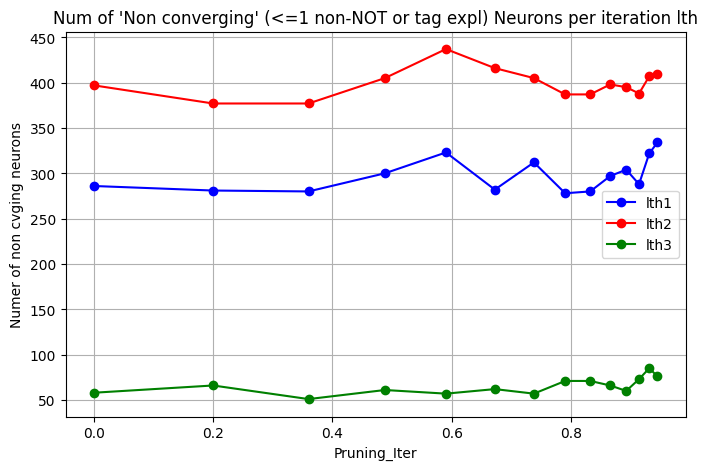

In [10]:
import matplotlib.pyplot as plt
base = "/workspace/CCE_NLI/BERT/exp/lottery_ticket/Run2Full_allneurons/Expls"
num_neurons, inexplainable_lth_1 = nonconvg(base,1)
lth_sorted_keys = sorted(list(inexplainable_lth_1.keys()))
num_inexpl_neurons_lth1 = [len(inexplainable_lth_1[lth_sorted_keys[i]]) for i in range(len(lth_sorted_keys))]

x = [0, 0.2, 0.36, 0.4879999603599318, 0.5903999682879455, 0.6723199349902882, 0.7378560669124351, 0.7902848138898799, 0.832227870931938, 0.8657822967455504, 0.8926258572164744, 0.914100765053316, 0.9312805724025845, 0.9450244777421017]
num_neurons, inexplainable_lth_2 = nonconvg(base,2)
lth_sorted_keys = sorted(list(inexplainable_lth_2.keys()))
num_inexpl_neurons_lth2 = [len(inexplainable_lth_2[lth_sorted_keys[i]]) for i in range(len(lth_sorted_keys))]

num_neurons, inexplainable_wanda_3 = nonconvg(base,3)
lth_sorted_keys = sorted(list(inexplainable_wanda_3.keys()))
num_inexpl_neurons_lth3 = [len(inexplainable_wanda_3[lth_sorted_keys[i]]) for i in range(len(lth_sorted_keys))]



# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(x, num_inexpl_neurons_lth1, label='lth1', marker='o', linestyle='-', color='blue')
plt.plot(x, num_inexpl_neurons_lth2, label='lth2', marker='o', linestyle='-', color='red')
plt.plot(x, num_inexpl_neurons_lth3, label='lth3', marker='o', linestyle='-', color='green')

# Customize the plot
plt.title("Num of 'Non converging' (<=1 non-NOT or tag expl) Neurons per iteration lth")
plt.xlabel("Pruning_Iter")
plt.ylabel("Numer of non cvging neurons")
plt.grid(True)  # Add grid lines
plt.legend()  # Show labels
# Display the plot
plt.show()

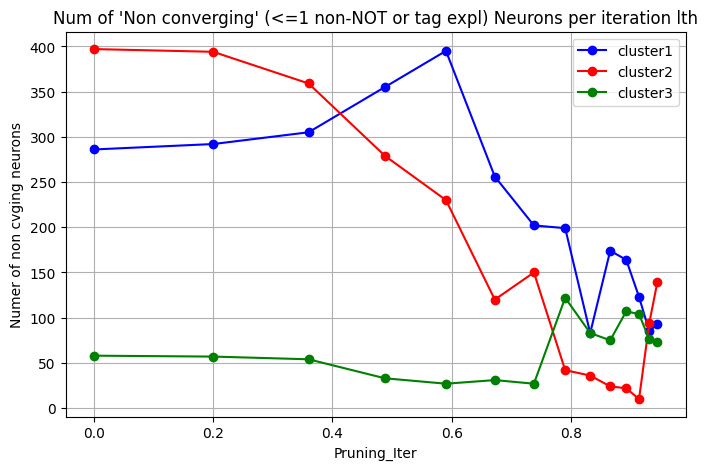

In [12]:
import matplotlib.pyplot as plt
base = "/workspace/CCE_NLI/BERT/exp/wanda/Run2Full/Expls"
num_neurons, inexplainable_wanda_1 = nonconvg(base,1)
wanda_sorted_keys = sorted(list(inexplainable_wanda_1.keys()))
num_inexpl_neurons_wanda1 = [len(inexplainable_wanda_1[wanda_sorted_keys[i]]) for i in range(len(wanda_sorted_keys))]

x = [0, 0.2, 0.36, 0.4879999603599318, 0.5903999682879455, 0.6723199349902882, 0.7378560669124351, 0.7902848138898799, 0.832227870931938, 0.8657822967455504, 0.8926258572164744, 0.914100765053316, 0.9312805724025845, 0.9450244777421017]
num_neurons, inexplainable_wanda_2 = nonconvg(base,2)
wanda_sorted_keys = sorted(list(inexplainable_wanda_2.keys()))
num_inexpl_neurons_wanda2 = [len(inexplainable_wanda_2[wanda_sorted_keys[i]]) for i in range(len(wanda_sorted_keys))]

num_neurons, inexplainable_wanda_3 = nonconvg(base,3)
wanda_sorted_keys = sorted(list(inexplainable_wanda_3.keys()))
num_inexpl_neurons_wanda3 = [len(inexplainable_wanda_3[wanda_sorted_keys[i]]) for i in range(len(wanda_sorted_keys))]



# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(x, num_inexpl_neurons_wanda1, label='cluster1', marker='o', linestyle='-', color='blue')
plt.plot(x, num_inexpl_neurons_wanda2, label='cluster2', marker='o', linestyle='-', color='red')
plt.plot(x, num_inexpl_neurons_wanda3, label='cluster3', marker='o', linestyle='-', color='green')

# Customize the plot
plt.title("Num of 'Non converging' (<=1 non-NOT or tag expl) Neurons per iteration lth")
plt.xlabel("Pruning_Iter")
plt.ylabel("Numer of non cvging neurons")
plt.grid(True)  # Add grid lines
plt.legend()  # Show labels
# Display the plot
plt.show()

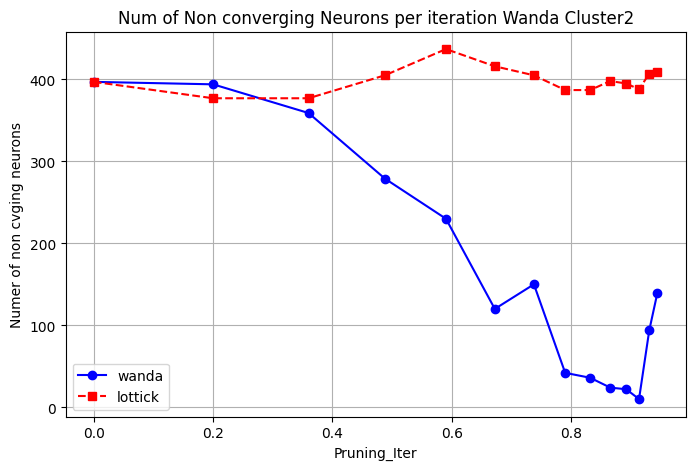

In [122]:
import matplotlib.pyplot as plt
base = "../../../wanda/Run2Full/Expls"
inexplainable_wanda_2 = nonconvg(base,2)
wanda_sorted_keys = sorted(list(inexplainable_wanda_2.keys()))
num_inexpl_neurons_wanda = [len(inexplainable_wanda_2[wanda_sorted_keys[i]]) for i in range(len(wanda_sorted_keys))]

x = [0, 0.2, 0.36, 0.4879999603599318, 0.5903999682879455, 0.6723199349902882, 0.7378560669124351, 0.7902848138898799, 0.832227870931938, 0.8657822967455504, 0.8926258572164744, 0.914100765053316, 0.9312805724025845, 0.9450244777421017]


base = "."
inexplainable_lot_2 = nonconvg(base,2)
num_inexpl_neurons_lot = [len(inexplainable_lot_2[list(inexplainable_lot_2.keys())[i]]) for i in range(len(inexplainable_lot_2))]

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(x, num_inexpl_neurons_wanda, label='wanda', marker='o', linestyle='-', color='blue')
plt.plot(x, num_inexpl_neurons_lot, label='lottick', marker='s', linestyle='--', color='red')


# Customize the plot
plt.title("Num of Non converging Neurons per iteration Wanda Cluster2")
plt.xlabel("Pruning_Iter")
plt.ylabel("Numer of non cvging neurons")
plt.grid(True)  # Add grid lines
plt.legend()  # Show labels
# Display the plot
plt.show()

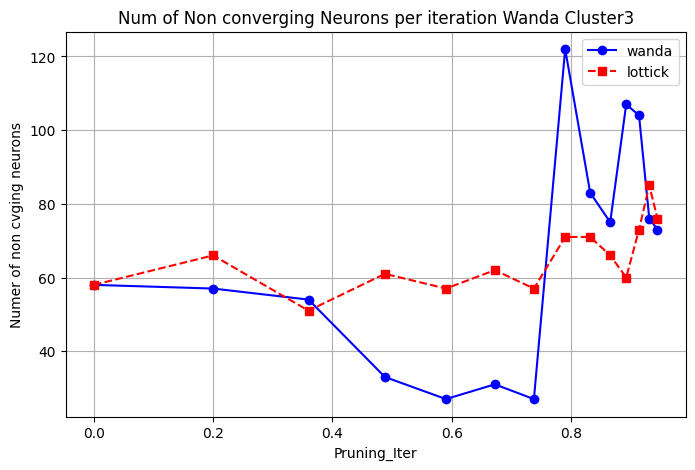

In [123]:
import matplotlib.pyplot as plt
base = "../../../wanda/Run2Full/Expls"
inexplainable_wanda_3 = nonconvg(base,3)
wanda_sorted_keys = sorted(list(inexplainable_wanda_3.keys()))
num_inexpl_neurons_wanda = [len(inexplainable_wanda_3[wanda_sorted_keys[i]]) for i in range(len(wanda_sorted_keys))]

x = [0, 0.2, 0.36, 0.4879999603599318, 0.5903999682879455, 0.6723199349902882, 0.7378560669124351, 0.7902848138898799, 0.832227870931938, 0.8657822967455504, 0.8926258572164744, 0.914100765053316, 0.9312805724025845, 0.9450244777421017]


base = "."
inexplainable_lot_3 = nonconvg(base,3)
num_inexpl_neurons_lot = [len(inexplainable_lot_3[list(inexplainable_lot_3.keys())[i]]) for i in range(len(inexplainable_lot_3))]

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(x, num_inexpl_neurons_wanda, label='wanda', marker='o', linestyle='-', color='blue')
plt.plot(x, num_inexpl_neurons_lot, label='lottick', marker='s', linestyle='--', color='red')


# Customize the plot
plt.title("Num of Non converging Neurons per iteration Wanda Cluster3")
plt.xlabel("Pruning_Iter")
plt.ylabel("Numer of non cvging neurons")
plt.grid(True)  # Add grid lines
plt.legend()  # Show labels
# Display the plot
plt.show()

In [78]:
sparsities = [0, 0.2, 0.36, 0.48, 0.59, 0.67, 0.73, 0.79, 0.83, 0.86, 0.89, 0.91, 0.93, 0.94]

WANDA_FINAL_ACCS= [0.858, 0.845, 0.773, 0.451, 0.339, 0.338, 0.338, 0.338, 0.338, 0.338, 0.338, 0.338, 0.338, 0.338]
LTH_FINAL_ACCS = [0.858, 0.857, 0.859, 0.859, 0.858, 0.855, 0.856, 0.856,  0.853, 0.850,0.844, 0.836,0.830, 0.830] #0.826]

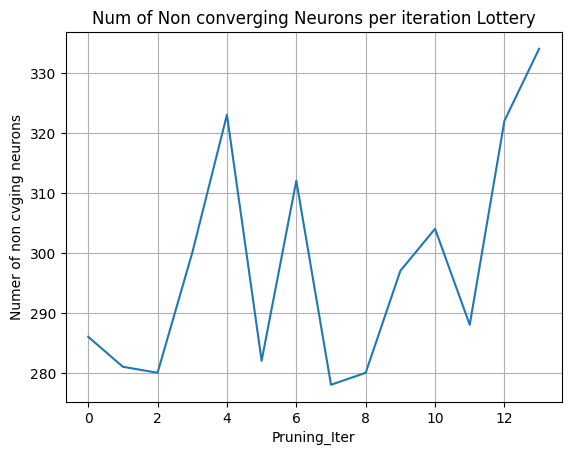

In [58]:
import matplotlib.pyplot as plt
base = "."
inexplainable = nonconvg(base)
num_inexpl_neurons = [len(inexplainable[list(inexplainable.keys())[i]]) for i in range(len(inexplainable))]
# Create the plot
plt.plot(num_inexpl_neurons)  # Plots numbers against their indices (0, 1, 2, ...)

# Customize the plot
plt.title("Num of Non converging Neurons per iteration Lottery")
plt.xlabel("Pruning_Iter")
plt.ylabel("Numer of non cvging neurons")
plt.grid(True)  # Add grid lines

# Display the plot
plt.show()

In [ ]:
inexplainable_lot_1
inexplainable_lot_2
inexplainable_lot_3

In [146]:
iterations_lot = list(inexplainable_lot_1.keys())
inexplainable_wanda_1[iterations_lot[0]] = inexplainable_lot_1[iterations_lot[0]]
iterations_wanda = sorted(inexplainable_wanda_1.keys())

In [151]:
for i,j in zip(iterations_lot,iterations_wanda):
    print(sorted(inexplainable_lot_1[i]))
    print(sorted(inexplainable_wanda_1[j]))
    break

[2, 5, 7, 12, 14, 16, 17, 20, 24, 29, 31, 32, 33, 34, 39, 42, 46, 47, 48, 51, 53, 69, 70, 78, 91, 92, 93, 96, 97, 98, 99, 100, 104, 105, 106, 107, 115, 118, 124, 125, 126, 130, 133, 137, 139, 140, 141, 142, 148, 150, 152, 153, 157, 160, 161, 167, 169, 170, 174, 177, 181, 184, 188, 191, 192, 198, 199, 202, 209, 212, 216, 218, 219, 224, 227, 228, 231, 235, 237, 239, 249, 252, 253, 256, 264, 266, 274, 279, 280, 281, 284, 287, 294, 303, 306, 310, 314, 317, 336, 337, 342, 343, 346, 347, 353, 355, 356, 367, 369, 370, 371, 373, 380, 382, 383, 386, 393, 398, 403, 404, 407, 412, 417, 420, 427, 428, 429, 434, 435, 436, 448, 452, 455, 459, 461, 465, 466, 467, 469, 476, 480, 487, 489, 490, 491, 493, 501, 506, 507, 509, 511, 514, 516, 522, 528, 530, 532, 536, 539, 540, 543, 547, 548, 554, 557, 564, 570, 572, 573, 578, 583, 591, 599, 607, 608, 611, 616, 617, 619, 625, 629, 632, 636, 639, 642, 648, 651, 652, 655, 661, 665, 666, 669, 670, 674, 681, 682, 684, 686, 690, 691, 692, 694, 698, 700, 704, 706

In [ ]:
inexplainable_wanda_1
inexplainable_wanda_2
inexplainable_wanda_3